# Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import time

# Download ECG5000

In [2]:
# ECG5000 is available directly from UCR archive
!wget -q "https://www.timeseriesclassification.com/aeon-toolkit/ECG5000.zip"
!unzip -q ECG5000.zip

# Load
train = pd.read_csv("ECG5000_TRAIN.txt", header=None, sep=r'\s+')
test  = pd.read_csv("ECG5000_TEST.txt",  header=None, sep=r'\s+')

# First column is label, rest is signal
X_train = train.iloc[:, 1:].values.astype(np.float32)
y_train = train.iloc[:, 0].values
X_test  = test.iloc[:, 1:].values.astype(np.float32)
y_test  = test.iloc[:, 0].values

# Encode labels to 0-indexed
le = LabelEncoder()
y_train = le.fit_transform(y_train).astype(np.int64)
y_test  = le.transform(y_test).astype(np.int64)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Sequence length: {X_train.shape[1]}")
print(f"Classes: {len(np.unique(y_train))}")

Train: (500, 140), Test: (4500, 140)
Sequence length: 140
Classes: 5


# Normalize and build DataLoaders

In [3]:
# Normalize per sample (zero mean, unit variance)
mean = X_train.mean(axis=1, keepdims=True)
std  = X_train.std(axis=1, keepdims=True) + 1e-8
X_train = (X_train - mean) / std

mean = X_test.mean(axis=1, keepdims=True)
std  = X_test.std(axis=1, keepdims=True) + 1e-8
X_test = (X_test - mean) / std

# Add channel dimension → (batch, 1, T)
X_train = torch.tensor(X_train).unsqueeze(1)
X_test  = torch.tensor(X_test).unsqueeze(1)
y_train = torch.tensor(y_train)
y_test  = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test),  batch_size=32, shuffle=False)

print(f"Input shape: {X_train.shape}")

Input shape: torch.Size([500, 1, 140])


In [9]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# CNN + temporal pooling

In [4]:
class CNN_TemporalPooling(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.network(x)
        x = self.gap(x).squeeze(-1)
        return self.classifier(x)

# CNN + LSTM

In [5]:
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=128,
                            num_layers=2, batch_first=True)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x)           # (batch, 128, T)
        x = x.permute(0, 2, 1)   # (batch, T, 128)
        _, (h_n, _) = self.lstm(x)
        x = h_n[-1]               # last layer hidden state
        return self.classifier(x)

# Training

In [6]:
def train_model(model, train_loader, test_loader, epochs=50, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_accuracies = [], []
    start = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Evaluate
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                preds = model(X_batch).argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(y_batch.numpy())

        acc = accuracy_score(all_labels, all_preds)
        train_losses.append(epoch_loss / len(train_loader))
        test_accuracies.append(acc)

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {train_losses[-1]:.4f} | Acc: {acc:.4f}")

    training_time = time.time() - start
    return train_losses, test_accuracies, training_time

# Run, Plot and record results

In [10]:
NUM_CLASSES = len(np.unique(y_train.numpy()))

print("Training CNN + Temporal Pooling...")
set_seed(42)
cnn_pool = CNN_TemporalPooling(NUM_CLASSES)
pool_losses, pool_accs, pool_time = train_model(cnn_pool, train_loader, test_loader)

print("\nTraining CNN + LSTM...")
set_seed(42)
cnn_lstm = CNN_LSTM(NUM_CLASSES)
lstm_losses, lstm_accs, lstm_time = train_model(cnn_lstm, train_loader, test_loader)

Training CNN + Temporal Pooling...
Epoch 10/50 | Loss: 0.3665 | Acc: 0.9102
Epoch 20/50 | Loss: 0.2657 | Acc: 0.9240
Epoch 30/50 | Loss: 0.2500 | Acc: 0.9271
Epoch 40/50 | Loss: 0.2257 | Acc: 0.9211
Epoch 50/50 | Loss: 0.2085 | Acc: 0.9304

Training CNN + LSTM...
Epoch 10/50 | Loss: 0.3054 | Acc: 0.9071
Epoch 20/50 | Loss: 0.2257 | Acc: 0.9311
Epoch 30/50 | Loss: 0.1946 | Acc: 0.9156
Epoch 40/50 | Loss: 0.1465 | Acc: 0.9307
Epoch 50/50 | Loss: 0.1146 | Acc: 0.9293


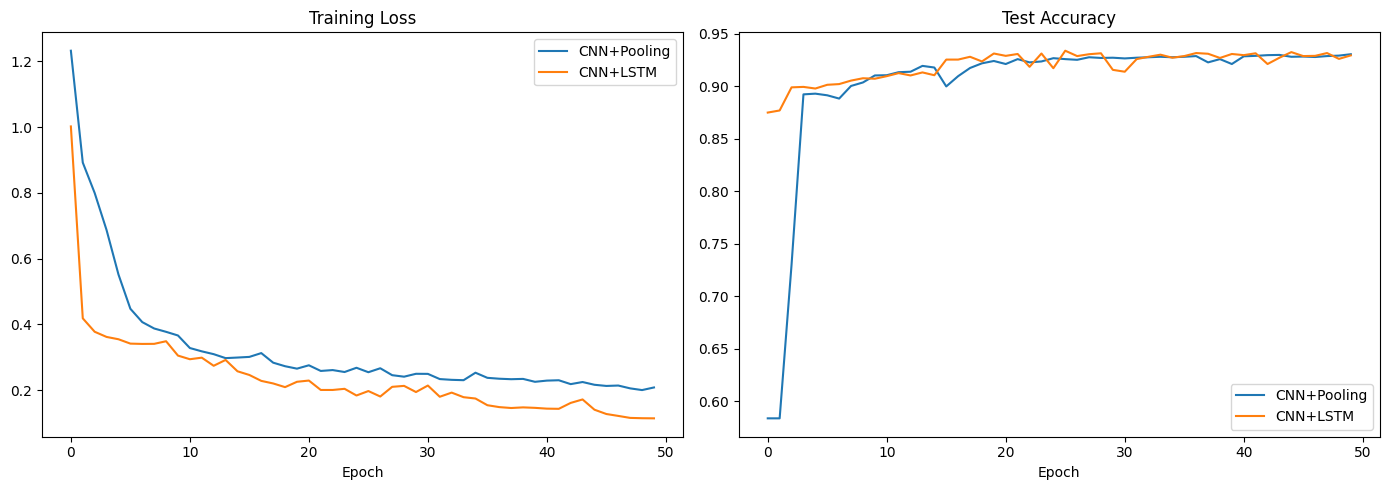


--- Final Results on ECG5000 ---
CNN+Pooling  | Acc: 0.9304 | Time: 57.1s | Params: 35909
CNN+LSTM     | Acc: 0.9338 | Time: 864.9s | Params: 300101


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pool_losses, label='CNN+Pooling')
axes[0].plot(lstm_losses, label='CNN+LSTM')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(pool_accs, label='CNN+Pooling')
axes[1].plot(lstm_accs, label='CNN+LSTM')
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n--- Final Results on ECG5000 ---")
print(f"CNN+Pooling  | Acc: {max(pool_accs):.4f} | Time: {pool_time:.1f}s | Params: {sum(p.numel() for p in cnn_pool.parameters())}")
print(f"CNN+LSTM     | Acc: {max(lstm_accs):.4f} | Time: {lstm_time:.1f}s | Params: {sum(p.numel() for p in cnn_lstm.parameters())}")

# Performance vs Sequence Length


Training with sequence length 20...
Epoch 10/50 | Loss: 0.2570 | Acc: 0.9224
Epoch 20/50 | Loss: 0.2039 | Acc: 0.9238
Epoch 30/50 | Loss: 0.1709 | Acc: 0.9233
Epoch 40/50 | Loss: 0.1688 | Acc: 0.9271
Epoch 50/50 | Loss: 0.1376 | Acc: 0.9238
Epoch 10/50 | Loss: 0.2940 | Acc: 0.9124
Epoch 20/50 | Loss: 0.1978 | Acc: 0.9213
Epoch 30/50 | Loss: 0.1750 | Acc: 0.9258
Epoch 40/50 | Loss: 0.1326 | Acc: 0.9240
Epoch 50/50 | Loss: 0.1208 | Acc: 0.9222
Length 20 | CNN+Pooling: 0.9293 | CNN+LSTM: 0.9276

Training with sequence length 40...
Epoch 10/50 | Loss: 0.2629 | Acc: 0.9222
Epoch 20/50 | Loss: 0.2164 | Acc: 0.9220
Epoch 30/50 | Loss: 0.2026 | Acc: 0.9229
Epoch 40/50 | Loss: 0.1785 | Acc: 0.9256
Epoch 50/50 | Loss: 0.1593 | Acc: 0.9271
Epoch 10/50 | Loss: 0.4291 | Acc: 0.8482
Epoch 20/50 | Loss: 0.3315 | Acc: 0.8578
Epoch 30/50 | Loss: 0.2560 | Acc: 0.8689
Epoch 40/50 | Loss: 0.2243 | Acc: 0.8796
Epoch 50/50 | Loss: 0.1874 | Acc: 0.8678
Length 40 | CNN+Pooling: 0.9271 | CNN+LSTM: 0.8824

Tra

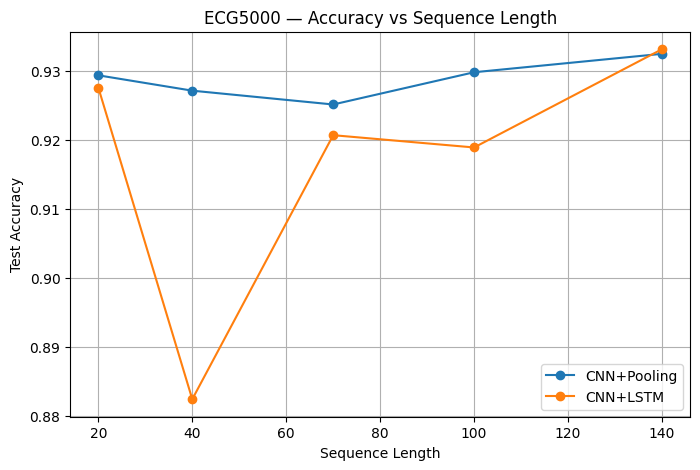

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lengths = [20, 40, 70, 100, 140]
pool_length_accs = []
lstm_length_accs = []

for length in lengths:
    print(f"\nTraining with sequence length {length}...")

    # Truncate
    X_train_short = X_train[:, :, :length]
    X_test_short  = X_test[:, :, :length]

    train_loader_s = DataLoader(TensorDataset(X_train_short, y_train), batch_size=32, shuffle=True)
    test_loader_s  = DataLoader(TensorDataset(X_test_short, y_test),   batch_size=32, shuffle=False)

    # CNN+Pooling
    set_seed(42)
    model_pool = CNN_TemporalPooling(NUM_CLASSES).to(device)
    _, accs_pool, _ = train_model(model_pool, train_loader_s, test_loader_s, epochs=50)
    pool_length_accs.append(max(accs_pool))

    # CNN+LSTM
    set_seed(42)
    model_lstm = CNN_LSTM(NUM_CLASSES).to(device)
    _, accs_lstm, _ = train_model(model_lstm, train_loader_s, test_loader_s, epochs=50)
    lstm_length_accs.append(max(accs_lstm))

    print(f"Length {length} | CNN+Pooling: {pool_length_accs[-1]:.4f} | CNN+LSTM: {lstm_length_accs[-1]:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(lengths, pool_length_accs, marker='o', label='CNN+Pooling')
plt.plot(lengths, lstm_length_accs, marker='o', label='CNN+LSTM')
plt.xlabel('Sequence Length')
plt.ylabel('Test Accuracy')
plt.title('ECG5000 — Accuracy vs Sequence Length')
plt.legend()
plt.grid(True)
plt.show()

# Performance vs Noise Level

Sigma 0.0 | CNN+Pooling: 0.9304 | CNN+LSTM: 0.9293
Sigma 0.1 | CNN+Pooling: 0.9293 | CNN+LSTM: 0.9300
Sigma 0.3 | CNN+Pooling: 0.9051 | CNN+LSTM: 0.9280
Sigma 0.5 | CNN+Pooling: 0.7284 | CNN+LSTM: 0.9182
Sigma 1.0 | CNN+Pooling: 0.5838 | CNN+LSTM: 0.8718


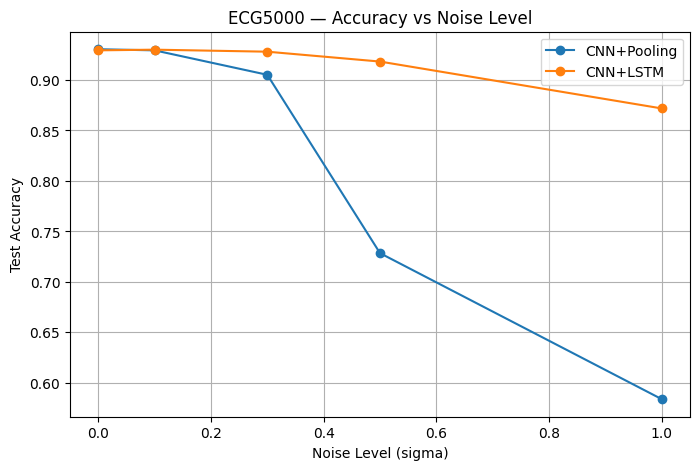

In [13]:
# Use the already trained models from Cell 7 — no retraining needed
# We are testing robustness of learned representations to noise

sigmas = [0.0, 0.1, 0.3, 0.5, 1.0]
pool_noise_accs = []
lstm_noise_accs = []

cnn_pool.eval()
cnn_lstm.eval()

for sigma in sigmas:
    pool_preds, lstm_preds, all_labels = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_noisy = X_batch.to(device) + sigma * torch.randn_like(X_batch).to(device)

            pool_pred = cnn_pool.to(device)(X_noisy).argmax(dim=1).cpu().numpy()
            lstm_pred = cnn_lstm.to(device)(X_noisy).argmax(dim=1).cpu().numpy()

            pool_preds.extend(pool_pred)
            lstm_preds.extend(lstm_pred)
            all_labels.extend(y_batch.numpy())

    pool_noise_accs.append(accuracy_score(all_labels, pool_preds))
    lstm_noise_accs.append(accuracy_score(all_labels, lstm_preds))
    print(f"Sigma {sigma:.1f} | CNN+Pooling: {pool_noise_accs[-1]:.4f} | CNN+LSTM: {lstm_noise_accs[-1]:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(sigmas, pool_noise_accs, marker='o', label='CNN+Pooling')
plt.plot(sigmas, lstm_noise_accs, marker='o', label='CNN+LSTM')
plt.xlabel('Noise Level (sigma)')
plt.ylabel('Test Accuracy')
plt.title('ECG5000 — Accuracy vs Noise Level')
plt.legend()
plt.grid(True)
plt.show()

# Summary table of all results

In [14]:
print("="*60)
print("FULL RESULTS SUMMARY — ECG5000")
print("="*60)

print("\n1. Baseline")
print(f"   CNN+Pooling : {max(pool_accs):.4f} | {pool_time:.1f}s | {sum(p.numel() for p in cnn_pool.parameters())} params")
print(f"   CNN+LSTM    : {max(lstm_accs):.4f} | {lstm_time:.1f}s | {sum(p.numel() for p in cnn_lstm.parameters())} params")

print("\n2. Accuracy vs Sequence Length")
print(f"   {'Length':<10} {'CNN+Pooling':<15} {'CNN+LSTM'}")
for l, p, q in zip(lengths, pool_length_accs, lstm_length_accs):
    print(f"   {l:<10} {p:<15.4f} {q:.4f}")

print("\n3. Accuracy vs Noise Level")
print(f"   {'Sigma':<10} {'CNN+Pooling':<15} {'CNN+LSTM'}")
for s, p, q in zip(sigmas, pool_noise_accs, lstm_noise_accs):
    print(f"   {s:<10} {p:<15.4f} {q:.4f}")

FULL RESULTS SUMMARY — ECG5000

1. Baseline
   CNN+Pooling : 0.9304 | 57.1s | 35909 params
   CNN+LSTM    : 0.9338 | 864.9s | 300101 params

2. Accuracy vs Sequence Length
   Length     CNN+Pooling     CNN+LSTM
   20         0.9293          0.9276
   40         0.9271          0.8824
   70         0.9251          0.9207
   100        0.9298          0.9189
   140        0.9324          0.9331

3. Accuracy vs Noise Level
   Sigma      CNN+Pooling     CNN+LSTM
   0.0        0.9304          0.9293
   0.1        0.9293          0.9300
   0.3        0.9051          0.9280
   0.5        0.7284          0.9182
   1.0        0.5838          0.8718
